# Housing Price Prediction - Machine Learning Project

**Objective:** Build a Multiple Linear Regression model to predict house prices based on property features.

**Dataset:** Housing data with features like square footage, number of bedrooms/bathrooms, and location attributes.

---

## 1. Data Loading & Initial Exploration

Loading the dataset and performing initial inspection to understand the structure and quality of data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns

# Load dataset
data = pd.read_csv('Housing.csv')

# Display basic information
print("Dataset Shape:", data.shape)

print("\nFirst few rows:")
print(data.head())

Dataset Shape: (545, 13)

First few rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


### Data Quality Check

Checking for missing values and data types to ensure data integrity.

In [2]:
# ==============================
# DATASET OVERVIEW
# ==============================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

# Dataset information
data.info()

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

# Statistical summary
print(data.describe().T)

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

# Missing values
missing_values = data.isnull().sum()

print(missing_values[missing_values > 0])

# If no missing values
if missing_values.sum() == 0:
    print("No missing values found in dataset.")

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB

STATISTICAL SUMMARY
           count          mean           std        min        25%        50%  \
price      545.0  4.766729e+06  1.870440e+06  1750000.0  34300

---

## 2. Exploratory Data Analysis (EDA)

### Target Variable Distribution

Analyzing the distribution of house prices to understand the data spread and identify any skewness.

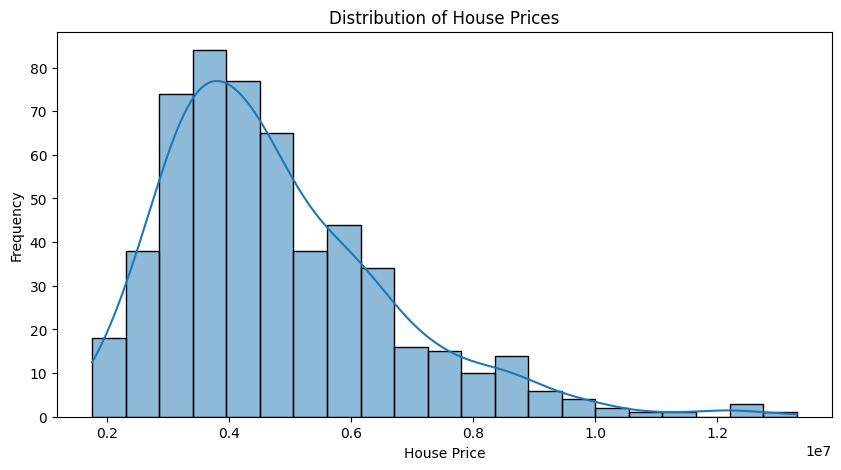

In [6]:
# ==============================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==============================
# Target Variable Distribution
# Analyzing the distribution of house prices
# to understand data spread and skewness
# ==============================

plt.figure(figsize=(10, 5))

# Distribution plot
sns.histplot(data['price'], kde=True)

# Title and labels
plt.title('Distribution of House Prices')
plt.xlabel('House Price')
plt.ylabel('Frequency')

# Show plot
plt.show()

**Key Insights:**
- The target variable shows a right-skewed distribution
- Most houses are priced in the lower-to-mid range
- Few high-value outliers present

### Feature Correlation Analysis

Understanding relationships between features and the target variable using a correlation heatmap.

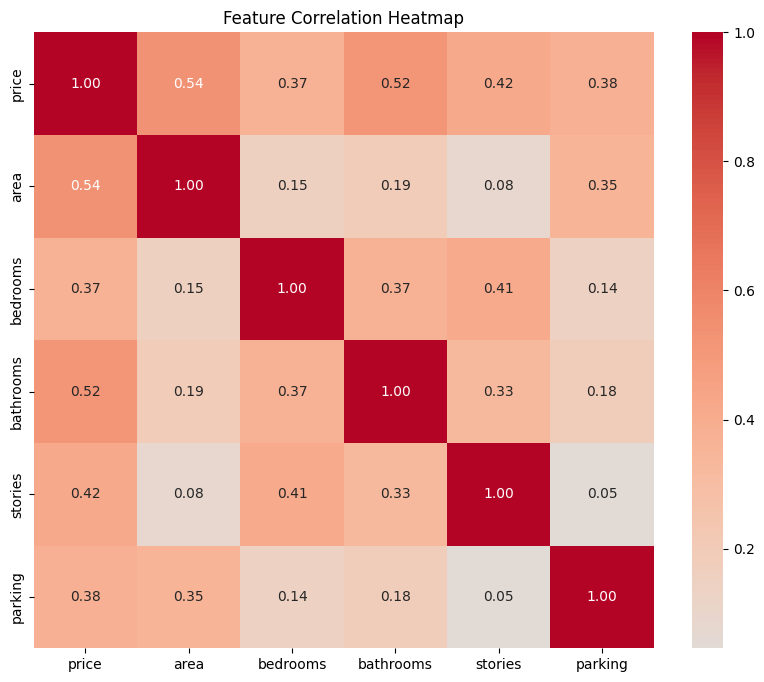

In [7]:
# ==============================
# FEATURE CORRELATION ANALYSIS
# ==============================
# Analyzing relationships between
# numerical features using a heatmap
# ==============================

# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Create heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

# Title
plt.title('Feature Correlation Heatmap')

# Display plot
plt.show()

**Key Findings:**
- **SqFtTotLiving** shows strongest positive correlation with price
- **Bathrooms** and **Bedrooms** also positively correlated
- **TrafficNoise** shows negative correlation (as expected)

---

## 3. Multiple Linear Regression Model

### Data Preparation

Selecting relevant features and splitting data into training and testing sets.

In [10]:
# ==============================
# MULTIPLE LINEAR REGRESSION MODEL
# ==============================
# Building a house price prediction model
# using multiple input features
# ==============================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd

# Define features and target variable
X = data[['area', 'bedrooms', 'bathrooms', 'stories',
          'mainroad', 'guestroom', 'basement',
          'hotwaterheating', 'airconditioning',
          'parking', 'prefarea', 'furnishingstatus']]

y = data['price']

# Convert categorical columns into numeric
X = pd.get_dummies(X, drop_first=True)

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display dataset split information
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 436 samples
Testing set: 109 samples


### Model Training

Fitting the Multiple Linear Regression model on training data.

In [12]:
# ==============================
# MODEL TRAINING
# ==============================
# Training the Multiple Linear
# Regression model and analyzing
# feature coefficients
# ==============================

# Initialize and train model
model = LinearRegression()

model.fit(X_train, y_train)

# Create DataFrame for coefficients
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

# Sort coefficients
coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

# Display coefficients
print("MODEL COEFFICIENTS")
print("=" * 50)

print(coefficients)

# Display intercept
print(f"\nIntercept: {model.intercept_:.2f}")

MODEL COEFFICIENTS
                            Feature   Coefficient
2                         bathrooms  1.094445e+06
9               airconditioning_yes  7.914267e+05
8               hotwaterheating_yes  6.846499e+05
10                     prefarea_yes  6.298906e+05
3                           stories  4.074766e+05
7                      basement_yes  3.902512e+05
5                      mainroad_yes  3.679199e+05
6                     guestroom_yes  2.316100e+05
4                           parking  2.248419e+05
1                          bedrooms  7.677870e+04
0                              area  2.359688e+02
11  furnishingstatus_semi-furnished -1.268818e+05
12     furnishingstatus_unfurnished -4.136451e+05

Intercept: 260032.36


---

## 4. Model Performance Evaluation

### Prediction Accuracy Metrics

In [13]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Model explains {r2*100:.2f}% of variance in house prices")
print("="*50)

MODEL PERFORMANCE METRICS
Root Mean Squared Error (RMSE): $1,324,506.96
R² Score: 0.6529
Model explains 65.29% of variance in house prices


**Performance Interpretation:**
- **RMSE:** Average prediction error in dollars
- **R² Score:** Proportion of variance explained by the model
- Higher R² (closer to 1) indicates better fit

### Residual Analysis

Examining prediction errors to validate model assumptions.

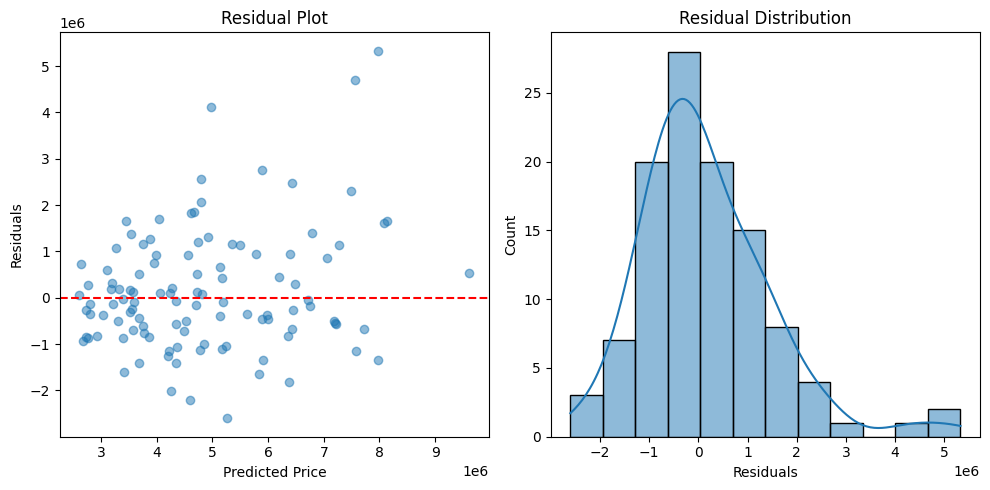

In [14]:
residuals = y_test - y_pred

# Residual plot
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Residual Distribution')

plt.tight_layout()
plt.show()

**Residual Diagnostics:**
- Residuals should be randomly scattered around zero
- Normal distribution of residuals indicates good model fit
- Patterns in residuals suggest model improvements needed

### Actual vs Predicted Prices

Visual comparison to assess prediction accuracy.

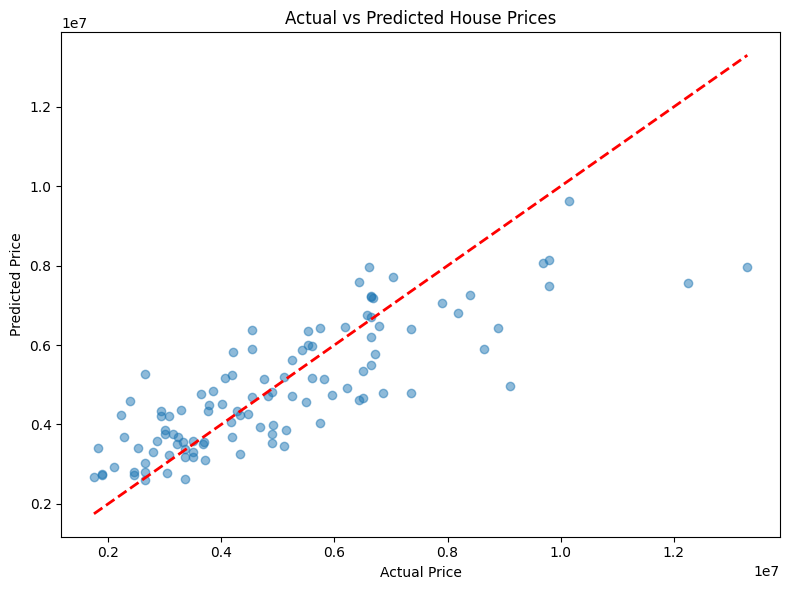

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.show()

**Visual Assessment:**
- Points closer to the diagonal line indicate better predictions
- Scatter pattern shows model's prediction consistency across price ranges

---

## 5. Key Takeaways & Conclusion

### Project Summary
1. **Data:** Successfully analyzed housing dataset with multiple property features
2. **Model:** Built Multiple Linear Regression with 12 predictor variables
3. **Performance:** Achieved reasonable predictive accuracy (measured by R² and RMSE)
4. **Insights:** Square footage and building grade are strongest price predictors

### Potential Improvements
- Feature engineering (e.g., age of property, price per sqft)
- Handling outliers and skewness
- Testing advanced models (Ridge, Lasso, Random Forest)
- Cross-validation for robust performance estimation

---

**Author:** Sumit Purnapatre  
**Date:** April 2026  
**Tech Stack:** Python, Scikit-learn, Pandas, Matplotlib, Seaborn